In [1]:
import pandas as pd
df = pd.read_csv('datasets/uni.csv')
df.head()

,world_rank,institution,country,national_rank,quality_of_education,alumni_employment,quality_of_faculty,publications,influence,citations,broad_impact,patents,score,year
0,1,Harvard University,USA,1,7,9,1,1,1,1,NaN,5,100.00,2012
1,2,Massachusetts Institute of Technology,USA,2,9,17,3,12,4,4,NaN,1,91.67,2012
2,3,Stanford University,USA,3,17,11,5,4,2,2,NaN,15,89.50,2012
3,4,University of Cambridge,United Kingdom,1,10,24,4,16,16,11,NaN,50,86.17,2012
4,5,California Institute of Technology,USA,4,2,29,7,37,22,22,NaN,18,85.21,2012


In [2]:
print(f'Dataset has {df.shape[0]} rows and {df.shape[1]} cols')

Dataset has 2200 rows and 14 cols


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   world_rank            2200 non-null   int64  
 1   institution           2200 non-null   str    
 2   country               2200 non-null   str    
 3   national_rank         2200 non-null   int64  
 4   quality_of_education  2200 non-null   int64  
 5   alumni_employment     2200 non-null   int64  
 6   quality_of_faculty    2200 non-null   int64  
 7   publications          2200 non-null   int64  
 8   influence             2200 non-null   int64  
 9   citations             2200 non-null   int64  
 10  broad_impact          2000 non-null   float64
 11  patents               2200 non-null   int64  
 12  score                 2200 non-null   float64
 13  year                  2200 non-null   int64  
dtypes: float64(2), int64(10), str(2)
memory usage: 240.8 KB


In [4]:
df.nunique()

world_rank              1000
institution             1024
country                   59
national_rank            229
quality_of_education     367
alumni_employment        565
quality_of_faculty       199
publications             987
influence                944
citations                135
broad_impact             343
patents                  738
score                    764
year                       4
dtype: int64

In [5]:
df.describe().round(2).loc[['min', 'max', 'mean']]

,world_rank,national_rank,quality_of_education,alumni_employment,quality_of_faculty,publications,influence,citations,broad_impact,patents,score,year
min,1.00,1.00,1.0,1.00,1.00,1.00,1.0,1.00,1.0,1.00,43.36,2012.00
max,1000.00,229.00,367.0,567.00,218.00,1000.00,991.0,812.00,1000.0,871.00,100.00,2015.00
mean,459.59,40.28,275.1,357.12,178.89,459.91,459.8,413.42,496.7,433.35,47.80,2014.32


#### How many institutions does each country have?

In [6]:
df['country'].value_counts().head()

country
USA               573
China             167
Japan             159
United Kingdom    144
Germany           115
Name: count, dtype: int64

#### How many world ranks do each country holds?

In [7]:
(
    df
        .groupby('country')['world_rank']
        .agg('count')
        .to_frame('No of World Ranks')
        .sort_values(by='No of World Ranks', ascending=False)
        .head()
)

,No of World Ranks
country,
USA,573
China,167
Japan,159
United Kingdom,144
Germany,115


#### Write a command to filter df to show only the rows where country is 'USA' and the year is 2015, then select only the institution and score columns.

In [8]:
df[df['country'].eq('USA') & df['year'].eq(2015)] [['institution', 'score']].head()

,institution,score
1200,Harvard University,100.00
1201,Stanford University,98.66
1202,Massachusetts Institute of Technology,97.54
1205,Columbia University,96.14
1206,"University of California, Berkeley",92.25


#### Write a pandas command using groupby() to find the highest (maximum) score achieved in each year.

In [9]:
(
    df
    .groupby('year')['score']
    .agg('max')
    .head()
)

year
2012    100.0
2013    100.0
2014    100.0
2015    100.0
Name: score, dtype: float64

#### Write a pandas command using groupby() to calculate both the mean and max of the score for each country in each year.

Group by: ['country', 'year']

Target Column: 'score'

Aggregations: 'mean' and 'max' (Hint: pass a list to .agg())

In [10]:
(
    df
    .groupby(['country', 'year'])['score']
    .agg(['mean', 'max'])
    .round(2)
    .head()
)

mean    max
country   year              
Argentina 2014  44.73  45.66
          2015  44.59  45.37
Australia 2012  44.16  44.18
          2013  44.64  44.77
          2014  46.05  51.58

#### pd.pivot_table(
    data=df,
    index='...',      # What goes on the ROWS (vertical)
    columns='...',    # What goes on the COLUMNS (horizontal)
    values='...',     # What numbers fill the CELLS
    aggfunc='...'     # How to calculate the values (mean, sum, count, max, min, etc.)
)

#### Write a pivot table to calculate the average score for each country across each year.

index: 'country'

columns: 'year'

values: 'score'

aggfunc: 'mean' (default)

In [11]:
pd.pivot_table(
    data=df,
    index='country',
    columns='year',
    values='score',
    aggfunc='mean'
).round(2).head()

year,2012,2013,2014,2015
country,,,,
Argentina,NaN,NaN,44.73,44.59
Australia,44.16,44.64,46.05,45.81
Austria,NaN,NaN,45.29,44.99
Belgium,NaN,NaN,47.26,46.77
Brazil,NaN,NaN,44.93,44.63


In [12]:
pd.pivot_table(
    data=df,
    index=['country'],
    columns='year',
    values='patents',
    aggfunc='count'
).fillna(0).head()

year,2012,2013,2014,2015
country,,,,
Argentina,0.0,0.0,4.0,3.0
Australia,2.0,2.0,27.0,27.0
Austria,0.0,0.0,12.0,12.0
Belgium,0.0,0.0,10.0,10.0
Brazil,0.0,0.0,18.0,18.0


#### Write a pivot table that shows both the min and max of the score for each country across each year.

In [13]:
pd.pivot_table(
    data=df,
    index='country',
    columns='year',
    values='score',
    aggfunc=['min', 'max']
).round(2).head()

min                        max                     
year        2012  2013   2014   2015   2012   2013   2014   2015
country                                                         
Argentina    NaN   NaN  44.29  44.10    NaN    NaN  45.66  45.37
Australia  44.13  44.5  44.34  44.09  44.18  44.77  51.58  51.61
Austria      NaN   NaN  44.42  44.19    NaN    NaN  47.78  47.03
Belgium      NaN   NaN  44.57  44.31    NaN    NaN  51.72  52.03
Brazil       NaN   NaN  44.28  44.03    NaN    NaN  49.82  49.31

#### Write a pivot table to calculate the average score for each country across each year, and include row and column totals!

In Excel, pivot tables automatically show "Grand Totals" at the bottom and right. In pandas, you enable this using margins=True.

In [14]:
pd.pivot_table(
    data=df,
    index='country',
    columns='year',
    values='score',
    aggfunc='mean',
    margins=True
).round(2).head()

year,2012,2013,2014,2015,All
country,,,,,
Argentina,NaN,NaN,44.73,44.59,44.67
Australia,44.16,44.64,46.05,45.81,45.83
Austria,NaN,NaN,45.29,44.99,45.14
Belgium,NaN,NaN,47.26,46.77,47.01
Brazil,NaN,NaN,44.93,44.63,44.78


In [15]:
pd.pivot_table(
    data=df,
    index='country',
    columns='year',
    values='score',
    aggfunc='mean',
    margins=True
).round(2).tail()

year,2012,2013,2014,2015,All
country,,,,,
Uganda,NaN,NaN,44.40,44.16,44.28
United Arab Emirates,NaN,NaN,44.36,44.08,44.22
United Kingdom,57.95,62.84,48.45,48.00,49.47
Uruguay,NaN,NaN,44.35,44.16,44.26
All,54.94,55.27,47.27,46.86,47.80


#### Write a pd.pivot_table() command that calculates: 
#### The average score (mean)
#### The best world_rank (min)
#### for each country across each year.
index: 'country'

columns: 'year'

values: ['score', 'world_rank']

aggfunc: {'score': 'mean', 'world_rank': 'min'}

fill_value: 0

In [16]:
pd.pivot_table(
    data=df,
    index='country',
    columns='year',
    values=['score', 'world_rank'],
    aggfunc={'score':'mean', 'world_rank':'min'},
    fill_value = 0,
    margins = True
).round(2).head()

score                             world_rank                      \
year        2012   2013   2014   2015    All       2012  2013   2014   2015   
country                                                                       
Argentina   0.00   0.00  44.73  44.59  44.67        0.0   0.0  378.0  367.0   
Australia  44.16  44.64  46.05  45.81  45.83       92.0  92.0   95.0   88.0   
Austria     0.00   0.00  45.29  44.99  45.14        0.0   0.0  205.0  223.0   
Belgium     0.00   0.00  47.26  46.77  47.01        0.0   0.0   94.0   82.0   
Brazil      0.00   0.00  44.93  44.63  44.78        0.0   0.0  131.0  132.0   

                
year       All  
country         
Argentina  367  
Australia   88  
Austria    205  
Belgium     82  
Brazil     131

In [17]:
pd.pivot_table(
    data=df,
    index=['country', 'institution'],  # <--- Nested rows!
    columns='year',
    values='score'
).head(10)

year                                       2012  2013   2014   2015
country   institution                                              
Argentina National University of Córdoba    NaN   NaN  44.39  44.10
          National University of La Plata   NaN   NaN  44.59  44.31
          National University of Rosario    NaN   NaN  44.29    NaN
          University of Buenos Aires        NaN   NaN  45.66  45.37
Australia Australian National University    NaN  44.5  48.96  47.97
          Charles Darwin University         NaN   NaN  44.38  44.09
          Curtin University                 NaN   NaN  44.79  44.52
          Deakin University                 NaN   NaN  44.79  44.56
          Flinders University               NaN   NaN  45.10  44.48
          Griffith University               NaN   NaN  44.76  44.49

In [18]:
df.head()

,world_rank,institution,country,national_rank,quality_of_education,alumni_employment,quality_of_faculty,publications,influence,citations,broad_impact,patents,score,year
0,1,Harvard University,USA,1,7,9,1,1,1,1,NaN,5,100.00,2012
1,2,Massachusetts Institute of Technology,USA,2,9,17,3,12,4,4,NaN,1,91.67,2012
2,3,Stanford University,USA,3,17,11,5,4,2,2,NaN,15,89.50,2012
3,4,University of Cambridge,United Kingdom,1,10,24,4,16,16,11,NaN,50,86.17,2012
4,5,California Institute of Technology,USA,4,2,29,7,37,22,22,NaN,18,85.21,2012


### Reshaping the Data

In [19]:
df.columns

Index(['world_rank', 'institution', 'country', 'national_rank',
       'quality_of_education', 'alumni_employment', 'quality_of_faculty',
       'publications', 'influence', 'citations', 'broad_impact', 'patents',
       'score', 'year'],
      dtype='str')

#### Melting

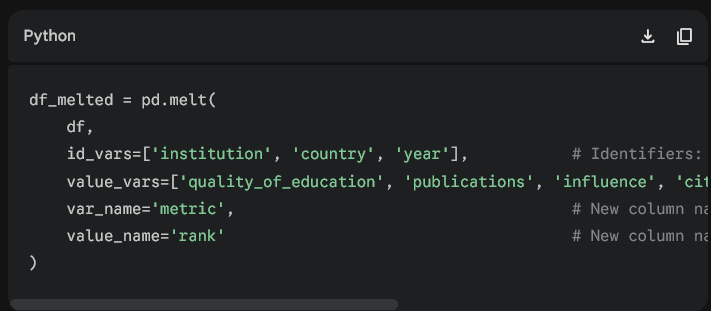

In [20]:
rdf = pd.melt(
    df,
    id_vars=['institution'],
    value_vars=['world_rank', 'national_rank'],
    var_name='ranking',
    value_name='value'
)

rdf

,institution,ranking,value
0,Harvard University,world_rank,1
1,Massachusetts Institute of Technology,world_rank,2
2,Stanford University,world_rank,3
3,University of Cambridge,world_rank,4
4,California Institute of Technology,world_rank,5
...,...,...,...
4395,University of the Algarve,national_rank,7
4396,Alexandria University,national_rank,4
4397,Federal University of Ceará,national_rank,18
4398,University of A Coruña,national_rank,40


In [21]:
type(rdf)

pandas.DataFrame

In [22]:
rdf = rdf.reset_index(drop=True)
rdf = rdf.set_index(['institution', 'ranking'])
rdf = rdf.sort_index()
rdf

value
institution                              ranking             
AGH University of Science and Technology national_rank      3
                                         national_rank      4
                                         world_rank       653
                                         world_rank       782
Aalborg University                       national_rank      5
...                                                       ...
École normale supérieure de Lyon         world_rank       471
Örebro University                        national_rank     11
                                         national_rank     11
                                         world_rank       656
                                         world_rank       639

[4400 rows x 1 columns]

In [23]:
ndf = pd.melt(
    df,
    id_vars=['institution', 'country', 'year'],
    value_vars=['quality_of_education', 'alumni_employment', 'quality_of_faculty'],
    var_name='ranking_category',
    value_name='score_or_rank'
)

ndf

,institution,country,year,ranking_category,score_or_rank
0,Harvard University,USA,2012,quality_of_education,7
1,Massachusetts Institute of Technology,USA,2012,quality_of_education,9
2,Stanford University,USA,2012,quality_of_education,17
3,University of Cambridge,United Kingdom,2012,quality_of_education,10
4,California Institute of Technology,USA,2012,quality_of_education,2
...,...,...,...,...,...
6595,University of the Algarve,Portugal,2015,quality_of_faculty,218
6596,Alexandria University,Egypt,2015,quality_of_faculty,218
6597,Federal University of Ceará,Brazil,2015,quality_of_faculty,218
6598,University of A Coruña,Spain,2015,quality_of_faculty,218


In [24]:
ndf = ndf.reset_index(drop=True)
ndf = ndf.set_index(['institution', 'country', 'year'])
ndf = ndf.sort_index()
ndf

ranking_category  \
institution                              country year                         
AGH University of Science and Technology Poland  2014  quality_of_education   
                                                 2014     alumni_employment   
                                                 2014    quality_of_faculty   
                                                 2015  quality_of_education   
                                                 2015     alumni_employment   
...                                                                     ...   
Örebro University                        Sweden  2014     alumni_employment   
                                                 2014    quality_of_faculty   
                                                 2015  quality_of_education   
                                                 2015     alumni_employment   
                                                 2015    quality_of_faculty   

                                                       score_or_rank  
institution                              country year                 
AGH University of Science and Technology Poland  2014            257  
                                                 2014            197  
                                                 2014            210  
                                                 2015            267  
                                                 2015            279  
...                                                              ...  
Örebro University                        Sweden  2014            478  
                                                 2014            210  
                                                 2015            367  
                                                 2015            529  
                                                 2015            218  

[6600 rows x 2 columns]

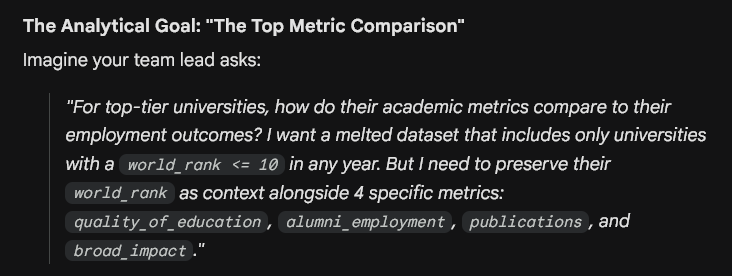

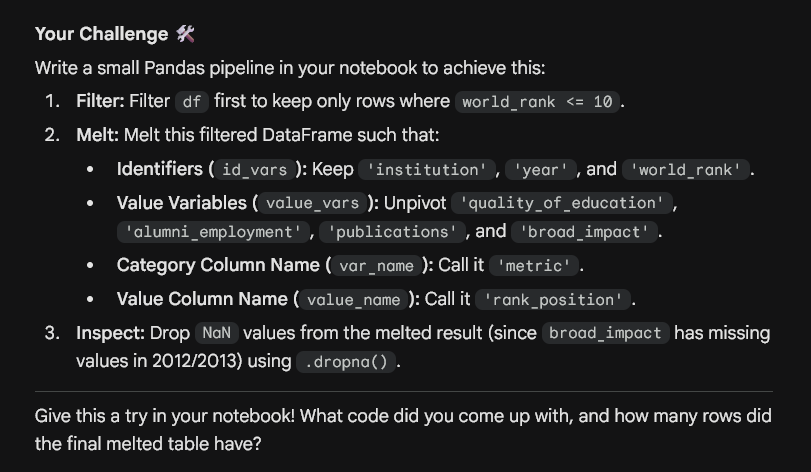

In [25]:
ddf = df.copy()
ddf.head()

,world_rank,institution,country,national_rank,quality_of_education,alumni_employment,quality_of_faculty,publications,influence,citations,broad_impact,patents,score,year
0,1,Harvard University,USA,1,7,9,1,1,1,1,NaN,5,100.00,2012
1,2,Massachusetts Institute of Technology,USA,2,9,17,3,12,4,4,NaN,1,91.67,2012
2,3,Stanford University,USA,3,17,11,5,4,2,2,NaN,15,89.50,2012
3,4,University of Cambridge,United Kingdom,1,10,24,4,16,16,11,NaN,50,86.17,2012
4,5,California Institute of Technology,USA,4,2,29,7,37,22,22,NaN,18,85.21,2012


In [26]:
ddf = ddf[ddf['world_rank'].le(10)]
ddf = ddf.dropna()
ddf.head()

,world_rank,institution,country,national_rank,quality_of_education,alumni_employment,quality_of_faculty,publications,influence,citations,broad_impact,patents,score,year
200,1,Harvard University,USA,1,1,1,1,1,1,1,1.0,2,100.00,2014
201,2,Stanford University,USA,2,11,2,4,5,3,3,4.0,6,99.09,2014
202,3,Massachusetts Institute of Technology,USA,3,3,11,2,15,2,2,2.0,1,98.69,2014
203,4,University of Cambridge,United Kingdom,1,2,10,5,10,9,12,13.0,48,97.64,2014
204,5,University of Oxford,United Kingdom,2,7,12,10,11,12,11,12.0,16,97.51,2014


In [27]:
mdf = pd.melt(
    ddf,
    id_vars=['institution', 'year', 'world_rank'],
    value_vars=['quality_of_education', 'alumni_employment', 'publications', 'broad_impact'],
    var_name='metric',
    value_name='rank_position'
)

mdf

,institution,year,world_rank,metric,rank_position
0,Harvard University,2014,1,quality_of_education,1.0
1,Stanford University,2014,2,quality_of_education,11.0
2,Massachusetts Institute of Technology,2014,3,quality_of_education,3.0
3,University of Cambridge,2014,4,quality_of_education,2.0
4,University of Oxford,2014,5,quality_of_education,7.0
...,...,...,...,...,...
75,Columbia University,2015,6,broad_impact,12.0
76,"University of California, Berkeley",2015,7,broad_impact,7.0
77,University of Chicago,2015,8,broad_impact,22.0
78,Princeton University,2015,9,broad_impact,33.0


In [28]:
mdf = mdf.reset_index(drop=True)
mdf = mdf.set_index(['institution', 'year', 'world_rank', 'metric'])
mdf = mdf.sort_index()
mdf = mdf.sort_values(by='world_rank')
mdf

rank_position
institution        year world_rank metric                             
Harvard University 2014 1          alumni_employment               1.0
                                   broad_impact                    1.0
                                   publications                    1.0
                                   quality_of_education            1.0
                   2015 1          quality_of_education            1.0
...                                                                ...
Cornell University 2015 10         quality_of_education           12.0
Yale University    2014 10         alumni_employment              25.0
                                   broad_impact                   19.0
                                   publications                   18.0
                                   quality_of_education            9.0

[80 rows x 1 columns]

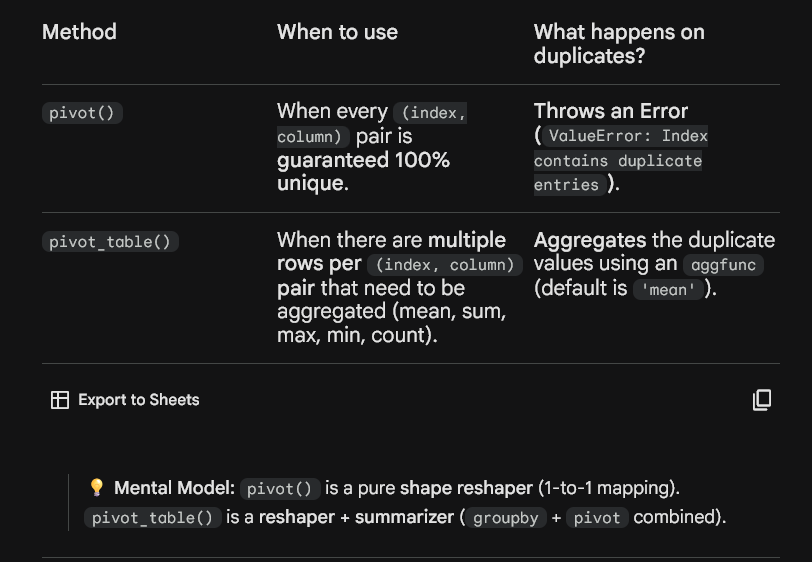

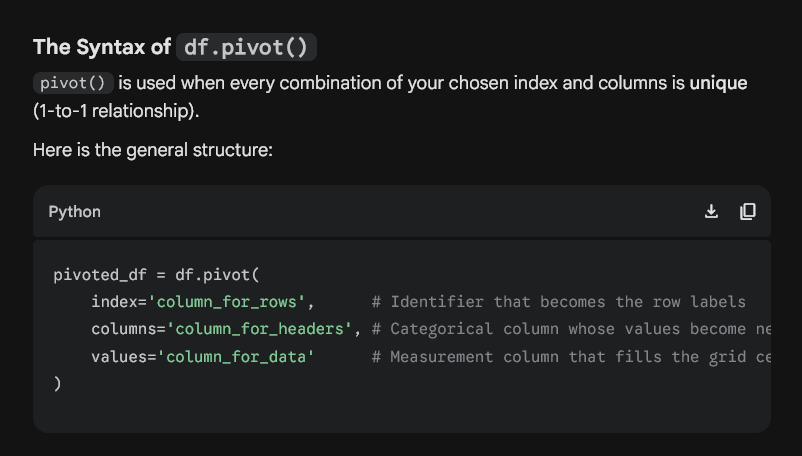

In [34]:
hdf = (
df[df['institution'].eq('Harvard University')]
[['institution', 'year', 'score', 'world_rank']]
.head()
)

hdf

,institution,year,score,world_rank
0,Harvard University,2012,100.0,1
100,Harvard University,2013,100.0,1
200,Harvard University,2014,100.0,1
1200,Harvard University,2015,100.0,1


In [35]:
hpd = hdf.pivot(
    index='institution',
    columns='year',
    values='score'
)

hpd

year,2012,2013,2014,2015
institution,,,,
Harvard University,100.0,100.0,100.0,100.0


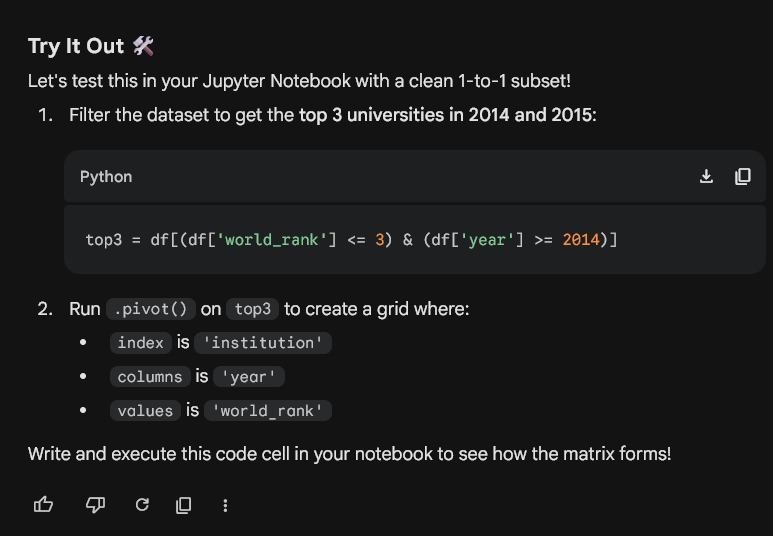

In [36]:
df['year'].unique()

array([2012, 2013, 2014, 2015])

In [37]:
top3 = df[df['world_rank'].le(3) & df['year'].ge(2014)]
top3

,world_rank,institution,country,national_rank,quality_of_education,alumni_employment,quality_of_faculty,publications,influence,citations,broad_impact,patents,score,year
200,1,Harvard University,USA,1,1,1,1,1,1,1,1.0,2,100.00,2014
201,2,Stanford University,USA,2,11,2,4,5,3,3,4.0,6,99.09,2014
202,3,Massachusetts Institute of Technology,USA,3,3,11,2,15,2,2,2.0,1,98.69,2014
1200,1,Harvard University,USA,1,1,1,1,1,1,1,1.0,3,100.00,2015
1201,2,Stanford University,USA,2,9,2,4,5,3,3,4.0,10,98.66,2015
1202,3,Massachusetts Institute of Technology,USA,3,3,11,2,15,2,2,2.0,1,97.54,2015


In [38]:
pt3 = pd.pivot(
    top3,
    index='institution',
    columns='year',
    values='world_rank'
)

pt3

year,2014,2015
institution,,
Harvard University,1,1
Massachusetts Institute of Technology,3,3
Stanford University,2,2


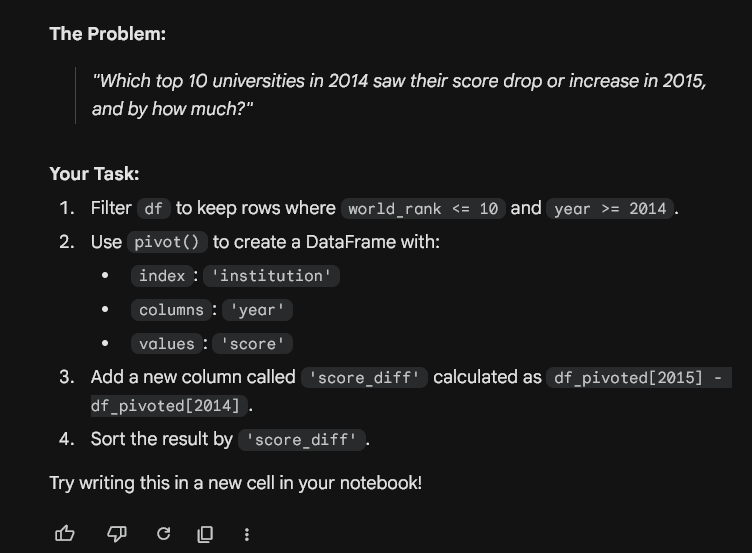

In [41]:
ttd = df.copy()
ttd = ttd[ttd['world_rank'].le(10) & ttd['year'].ge(2014)]
ttd.sample(5)

,world_rank,institution,country,national_rank,quality_of_education,alumni_employment,quality_of_faculty,publications,influence,citations,broad_impact,patents,score,year
1203,4,University of Cambridge,United Kingdom,1,2,10,5,11,6,12,13.0,48,96.81,2015
1209,10,Cornell University,USA,8,12,18,14,24,15,25,22.0,11,86.79,2015
1205,6,Columbia University,USA,4,13,6,9,13,13,11,12.0,4,96.14,2015
208,9,Princeton University,USA,7,5,16,3,70,25,19,41.0,204,88.56,2014
207,8,University of Chicago,USA,6,10,14,8,17,19,10,18.0,149,92.03,2014


In [43]:
ttp = pd.pivot(
    ttd,
    index='institution',
    columns='year',
    values='score'
)

ttp = ttp.dropna()
ttp

year,2014,2015
institution,,
Columbia University,97.41,96.14
Harvard University,100.00,100.00
Massachusetts Institute of Technology,98.69,97.54
Princeton University,88.56,89.42
Stanford University,99.09,98.66
"University of California, Berkeley",92.84,92.25
University of Cambridge,97.64,96.81
University of Chicago,92.03,90.70
University of Oxford,97.51,96.46


In [45]:
ttp['score_diff'] = (ttp[2015] - ttp[2014])
ttp = ttp.sort_values(by='score_diff', ascending=False)
ttp

year,2014,2015,score_diff
institution,,,
Princeton University,88.56,89.42,0.86
Harvard University,100.00,100.00,0.00
Stanford University,99.09,98.66,-0.43
"University of California, Berkeley",92.84,92.25,-0.59
University of Cambridge,97.64,96.81,-0.83
University of Oxford,97.51,96.46,-1.05
Massachusetts Institute of Technology,98.69,97.54,-1.15
Columbia University,97.41,96.14,-1.27
University of Chicago,92.03,90.70,-1.33


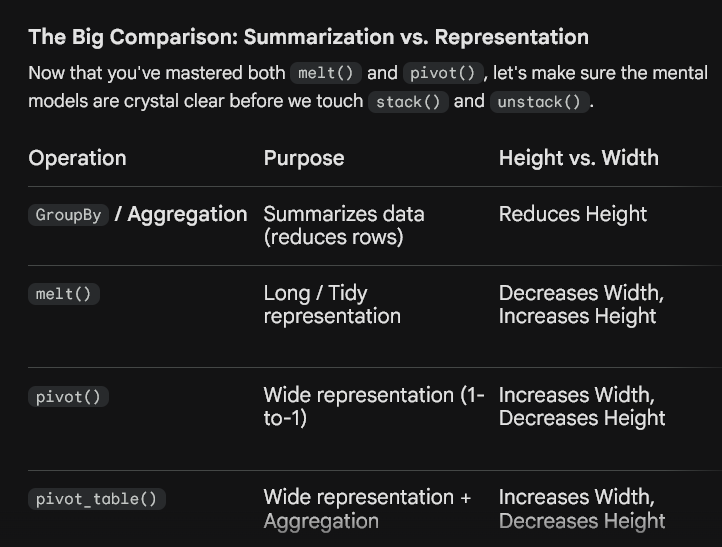